In [1]:
from nsdf_dark_matter.idx import load_all_data
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

home_directory = Path.home()
#print(home_directory)

cdms = load_all_data(str(home_directory)+'/idx/07180827_0000_F0002')


#07180827 is series
#07 minnesota
#Rest is date. This was August 27th, 2018
#0000 is  (hr/min?)
#F0001 is first dump of series (has random noise info frmo self-triggers)


event_ids = cdms.get_event_ids()
#print(event_ids)
metadata = cdms.get_event_metadata(event_ids[1])
print(metadata)
detector_ids = cdms.get_detector_ids()
#print(detector_ids)
channel_data = cdms.get_detector_channels(detector_ids[1])
#print(channel_data)


totev = np.shape(detector_ids)[0]/2
print(totev)

Trigger Type: Unknown, Readout Type: None, Global Timestamp: Monday, August 27, 2018 05:01:02 AM UTC
7592.0


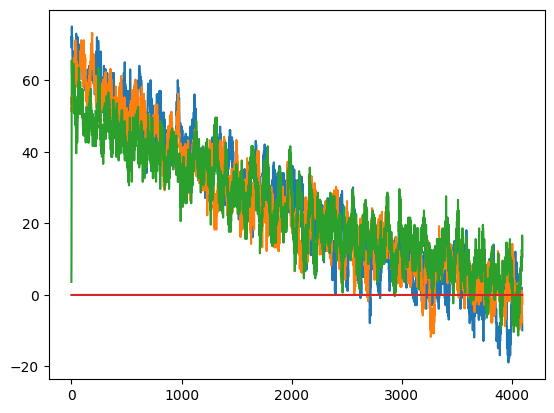

In [2]:
channel_data = cdms.get_detector_channels(detector_ids[4]) #15183 is highest ID for some reason (0 and 1 here is all 8 channels on one event, each is 0 and 2)
plt.plot(channel_data[0]-np.mean(channel_data[0][-100:]))
plt.plot(channel_data[1]-np.mean(channel_data[1][-100:]))
plt.plot(channel_data[2]-np.mean(channel_data[2][-100:]))
plt.plot(channel_data[3]-np.mean(channel_data[3][-100:]))
plt.show()

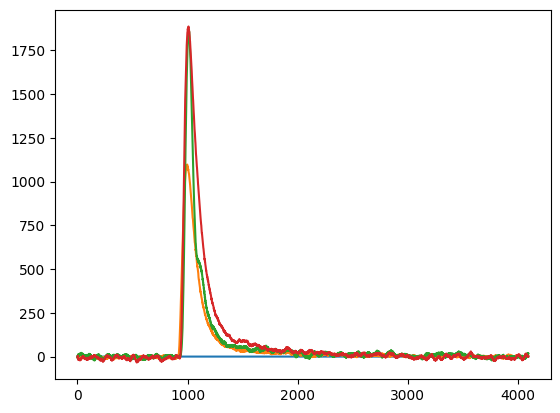

In [3]:
channel_data = cdms.get_detector_channels(detector_ids[121])
plt.plot(channel_data[0]-np.mean(channel_data[0][-100:]))
plt.plot(channel_data[1]-np.mean(channel_data[1][-100:]))
plt.plot(channel_data[2]-np.mean(channel_data[2][-100:]))
plt.plot(channel_data[3]-np.mean(channel_data[3][-100:]))
plt.show()

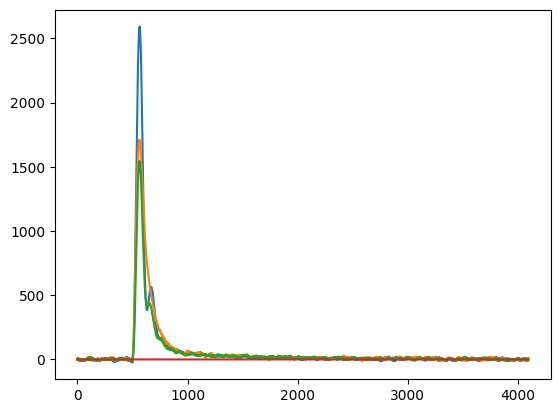

In [4]:
channel_data = cdms.get_detector_channels(detector_ids[122])
plt.plot(channel_data[0]-np.mean(channel_data[0][-100:]))
plt.plot(channel_data[1]-np.mean(channel_data[1][-100:]))
plt.plot(channel_data[2]-np.mean(channel_data[2][-100:]))
plt.plot(channel_data[3]-np.mean(channel_data[3][-100:]))
plt.show()

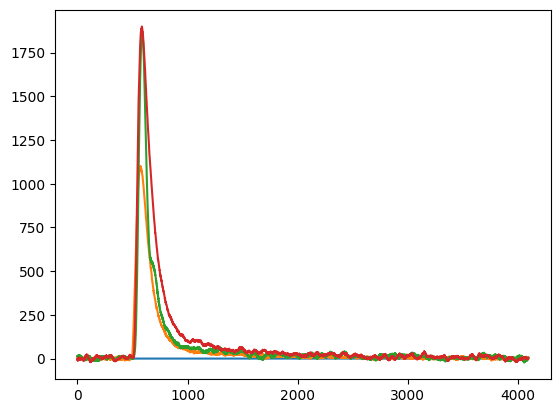

In [5]:
channel_data = cdms.get_detector_channels(detector_ids[123])
plt.plot(channel_data[0]-np.mean(channel_data[0][-100:]))
plt.plot(channel_data[1]-np.mean(channel_data[1][-100:]))
plt.plot(channel_data[2]-np.mean(channel_data[2][-100:]))
plt.plot(channel_data[3]-np.mean(channel_data[3][-100:]))
plt.show()

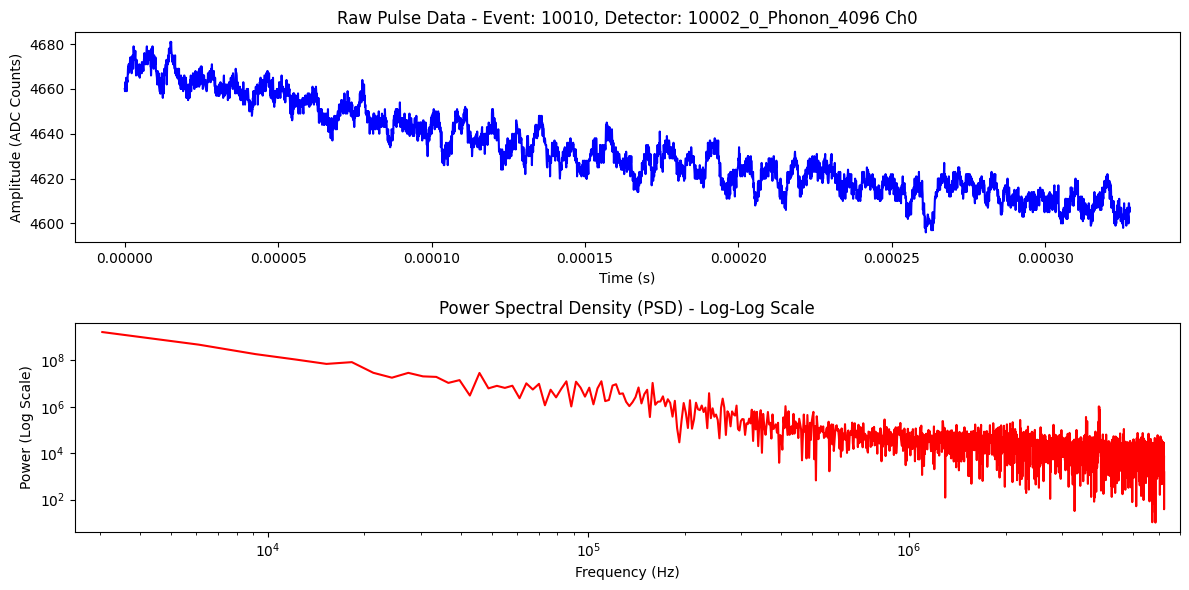

In [6]:
#AI-Generated

# ==========================================
# SECTION 1: IMPORTS
# ==========================================
from nsdf_dark_matter.idx import load_all_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def main():
    # ==========================================
    # SECTION 2: DATA LOADING & MATH
    # ==========================================
    home_directory = Path.home()
    cdms = load_all_data(str(home_directory) + '/idx/07180827_0000_F0002')
    
    event_id = cdms.get_event_ids() [10]
    #detector_ids = cdms.get_detectors_by_event(event_id)
    
    # Select the detector and its first channel for analysis
    det = detector_ids[4]
    channel_data = cdms.get_detector_channels(det)
    
    # Keep the raw signal exactly as it is in the file
    raw_signal = channel_data[1]
    
    # Sampling parameters
    fs = 1_250_0000       # 1.25 MHz sampling frequency for 0.8 microsecond resolution
    T = 1 / fs           # Sampling period in seconds
    N = len(raw_signal)  # Number of samples
    t = np.arange(N) * T # Time vector
    
    # Compute the Fast Fourier Transform[cite: 1]
    fft_signal = np.fft.fft(raw_signal)
    
    # Compute the corresponding frequency vector[cite: 1]
    f = np.fft.fftfreq(N, T)
    
    # Calculate Magnitude and Power Spectral Density (PSD)
    magnitude = np.abs(fft_signal)
    psd = magnitude ** 2
    
    # ==========================================
    # SECTION 3: PLOTTING SETUP
    # ==========================================
    # Set the overall window size
    plt.figure(figsize=(12, 6))
    
    # ==========================================
    # SECTION 4: PLOT 1 - RAW PULSE (TIME DOMAIN)
    # ==========================================
    # subplot(2, 1, 1) means: 2 rows, 1 column, draw in the 1st position
    plt.subplot(2, 1, 1)
    plt.plot(t, raw_signal, color='blue')
    plt.title(f"Raw Pulse Data - Event: {event_id}, Detector: {det} Ch0")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (ADC Counts)')
    
    # ==========================================
    # SECTION 5: PLOT 2 - PSD (FREQUENCY DOMAIN)
    # ==========================================
    # subplot(2, 1, 2) means: 2 rows, 1 column, draw in the 2nd position
    plt.subplot(2, 1, 2)
    
    # Slicing [1:N//2] skips the 0 Hz component and only plots positive frequencies[cite: 1]
    plt.plot(f[1:N//2], psd[1:N//2], color='red')
    plt.title('Power Spectral Density (PSD) - Log-Log Scale')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (Log Scale)')
    
    # Zoom in on the X-axis 
    # (Note: Max possible frequency here is Nyquist limit: fs/2 = 625,000 Hz)
    plt.xlim(2500, 7000000)
    
    # Change both axes to a logarithmic scale to see the noise floor
    plt.yscale('log')
    plt.xscale('log')
    
    # Clean up layout spacing and display
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

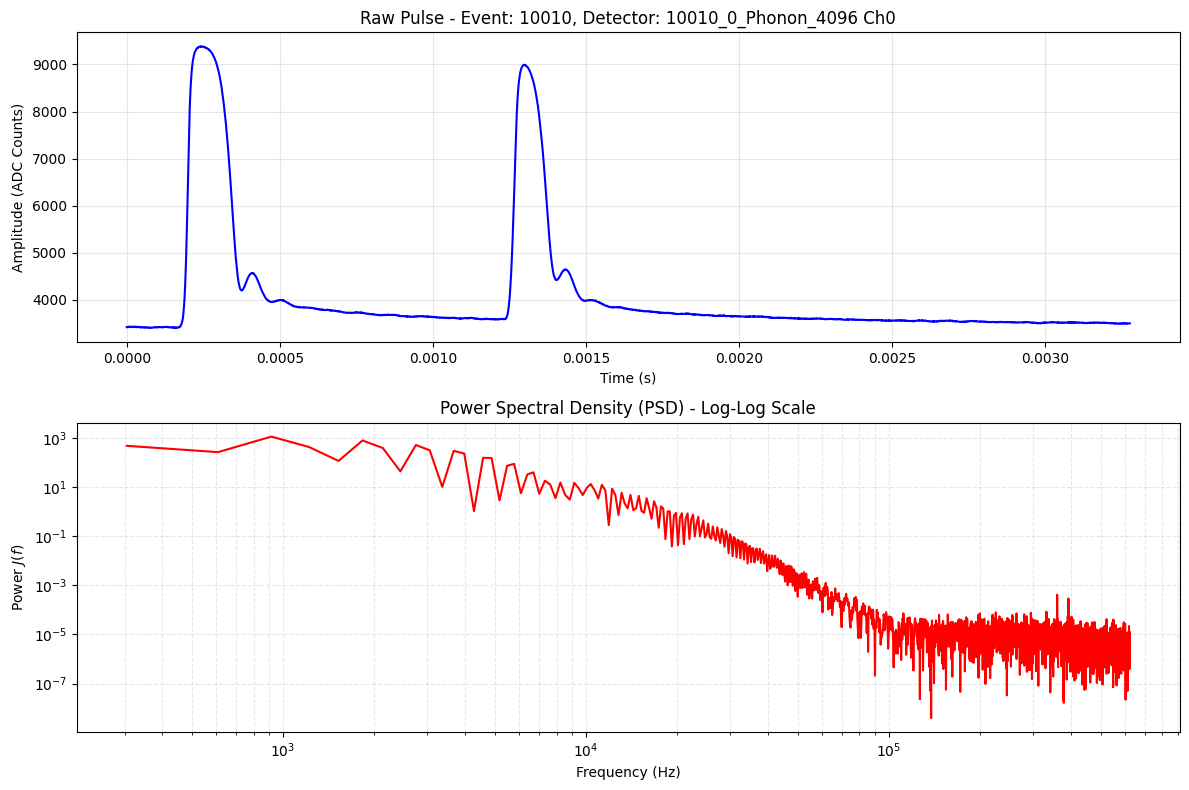

In [7]:
#AI-Generated (New Fourier calculation based on Optimal Filter paper)

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from nsdf_dark_matter.idx import load_all_data

def main():
    # ==========================================
    # SECTION 1: DATA LOADING
    # ==========================================
    # Pointing directly to the specific dataset directory
    target_dir = Path.home() / 'idx' / '07180827_0000_F0002'
    cdms = load_all_data(str(target_dir))
    
    event_ids = cdms.get_event_ids()
    event_id = event_ids[10]
    
    detector_ids = cdms.get_detectors_by_event(event_id)
    
    # Selecting index 0 to safely stay within the standard 4-channel detector limit
    det = detector_ids[0]
    channel_data = cdms.get_detector_channels(det)
    raw_signal = channel_data[0]
    
    # ==========================================
    # SECTION 2: THEORETICAL PSD CALCULATION
    # ==========================================
    # Sampling parameters
    fs = 1_250_000       # Corrected to 1.25 MHz for 0.8 microsecond resolution
    dt = 1 / fs          # Sampling period in seconds
    N = len(raw_signal)  # Number of discrete samples
    t = np.arange(N) * dt # Time vector (seconds)
    
    # 1. Discrete Fast Fourier Transform
    V_k = np.fft.fft(raw_signal)
    
    # 2. Frequency vector mapping
    f = np.fft.fftfreq(N, dt)
    
    # 3. Continuous One-Sided Power Spectral Density
    # Applying the (2 * dt / N) normalization scalar derived from the reference physics
    psd = (2 * dt / N) * np.abs(V_k)**2
    
    # ==========================================
    # SECTION 3: VISUALIZATION
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Time Domain (Raw Pulse)
    ax1.plot(t, raw_signal, color='blue')
    ax1.set_title(f"Raw Pulse - Event: {event_id}, Detector: {det} Ch0")
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude (ADC Counts)')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Frequency Domain (One-Sided PSD)
    # Slicing [1:N//2] drops the 0 Hz DC offset and isolates positive frequencies
    ax2.plot(f[1:N//2], psd[1:N//2], color='red')
    ax2.set_title('Power Spectral Density (PSD) - Log-Log Scale')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel(r'Power $J(f)$')
    
    # Log-log scaling for noise floor visibility
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    
    # Optional: Constrain X-axis if you only want to view a specific frequency band
    # ax2.set_xlim(2500, fs/2) 
    ax2.grid(True, alpha=0.3, which="both", ls="--")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
#my recreation of above

#imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from nsdf_dark_matter.idx import load_all_data

#dataset
home_directory = Path.home()
cdms = load_all_data(str(home_directory)+'/idx/07180827_0000_F0002')
event_ids = cdms.get_event_ids()
#print(event_ids)
metadata = cdms.get_event_metadata(event_ids[0])
#print(metadata)
detector_ids = cdms.get_detector_ids()
#print(detector_ids)
channel_data = cdms.get_detector_channels(detector_ids[0])
#print(channel_data)
raw_signal = channel_data[0]
#print(raw_signal)

fs = 1_250_000           #sampling frequency in Hz
dt = 1 / fs              #time between samples (0.8 microsceonds)
N = len(raw_signal)      #sample count
t = np.arange(N) * dt    #data recording interval (time vector - acts as x axis in time domain when plttoing raw_singal)

#FFT
V_k = np.fft.fft(raw_signal) #This does the actual transform, outputting an array of complex numbers. (np.fft.rfft applies to real only data like ours, so could use that)
psd = (dt / N) * np.abs(V_k)**2 #finds the power (in PSD) from V_k (which is my pulse in the frequency domain). array spreads it into distribution. This describes the variance at each data point (for each pulse?). dt/N is normailization constant for PSD
#above is multiplied by 2 when calculating a one sided PSD from only real data (which is my case, so make sure that gets accounted for)
f = np.fft.fftfreq(N, dt) #Contructs x-axis of PSD, allowing power to be plotted against frequency in sensible units (Hz, not arbitrary) using the time between samples fs as a reference

#Above calculates the PSD for all pulses in data series. I need to loop the part that calulates the PSD, then average and plot that.







#Reminders:
    #It's valid to use the above when we consider pulses that are only noise (or the pulse frequencies would dominate and be unhelpful) and only consider "good" noise that excludes local changes and carrier information about continuous noise over time. This form a noise tempalte which we divide the signal template by to penalize noise.
    #Total power in time is equal to total energy in frequency (which I think allows us to use that domain for useful energy information)
    #

KeyboardInterrupt: 